# Decision Tree Classification – Heart Disease Prediction

## Dataset Description
Dataset: **Heart Disease Dataset**  
Objective: Predict whether a patient has heart disease based on medical attributes.

Target column:
- **0 → No Heart Disease**
- **1 → Heart Disease**


# Part A: Conceptual Questions

### 1. What is a Decision Tree?
A Decision Tree is a supervised machine learning algorithm used for classification and regression.  
It splits data step‑by‑step based on feature values and produces a tree‑like structure of decisions.

### 2. What is a Split Criterion?
A split criterion determines the best feature and threshold used to divide the dataset at each node.

### 3. Difference between Gini and Entropy
Gini Impurity measures the probability of misclassification.  
Entropy measures the amount of disorder in the dataset.

### 4. Why do Decision Trees Overfit?
Decision trees can keep splitting until every training example is perfectly classified, causing them to memorize noise.

### 5. Role of max_depth
max_depth controls how deep the tree can grow and helps prevent overfitting.


# Part B: Data Exploration

In [25]:
import pandas as pd

df = pd.read_csv('heart.csv')

print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())

df.head()

Shape of dataset: (1025, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [21]:
# Target and features

target = 'target'
features = df.columns.drop('target')

print("Target Column:", target)
print("Feature Columns:", list(features))

Target Column: target
Feature Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [4]:
# Missing values

print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [5]:
# Data types

print(df.dtypes)

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


## Basic Statistics

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


## Target Distribution

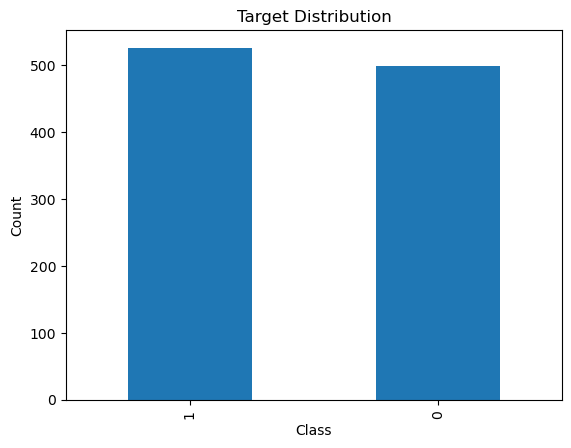

In [22]:
import matplotlib.pyplot as plt

df['target'].value_counts().plot(kind='bar')

plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## Feature Correlation

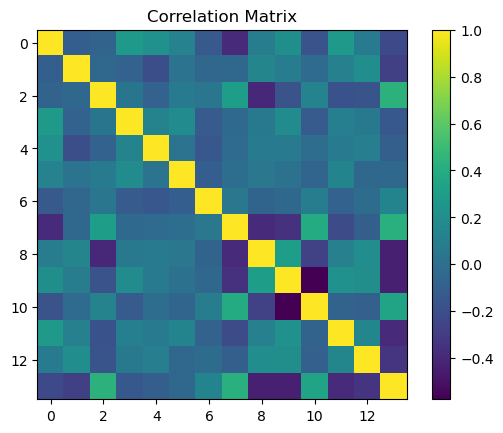

In [24]:
import matplotlib.pyplot as plt
corr = df.corr()

plt.imshow(corr)
plt.title("Correlation Matrix")
plt.colorbar()
plt.show()

# Part C: Data Preprocessing

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('target',axis=1)
y = df['target']

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)

print(X_train.shape,X_test.shape)

(820, 13) (205, 13)


# Part D: Model Building

In [11]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

model.fit(X_train,y_train)

y_pred = model.predict(X_test)

# Part E: Model Evaluation

In [12]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

acc = accuracy_score(y_test,y_pred)
cm = confusion_matrix(y_test,y_pred)
report = classification_report(y_test,y_pred)

print("Accuracy:",acc)
print("Confusion Matrix:\n",cm)
print("Classification Report:\n",report)

Accuracy: 0.9853658536585366
Confusion Matrix:
 [[102   0]
 [  3 100]]
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



### Interpretation
**Which class is predicted better?**
<p> <b>A:-</b> The class with higher <b>recall and F1 score</b> is predicted better.</p>

**Is the model overfitting or underfitting?**
<p> <b>A:-</b> If training accuracy is much higher than testing accuracy → <b>Overfitting</b></p>

# Part F: Tree Depth Experiment

In [13]:
from sklearn.metrics import accuracy_score

depths=[2,5,None]

results=[]

for d in depths:
    
    model = DecisionTreeClassifier(max_depth=d,random_state=42)
    model.fit(X_train,y_train)
    
    train_pred=model.predict(X_train)
    test_pred=model.predict(X_test)
    
    train_acc=accuracy_score(y_train,train_pred)
    test_acc=accuracy_score(y_test,test_pred)
    
    results.append((d,train_acc,test_acc))

results

[(2, 0.7695121951219512, 0.6780487804878049),
 (5, 0.9292682926829269, 0.8439024390243902),
 (None, 1.0, 0.9853658536585366)]

In [18]:
import pandas as pd

results_df = pd.DataFrame(results,columns=["max_depth","train_accuracy","test_accuracy"])
results_df["max_depth"] = results_df["max_depth"].fillna("None")
results_df

,max_depth,train_accuracy,test_accuracy
0,2.0,0.769512,0.678049
1,5.0,0.929268,0.843902
2,None,1.000000,0.985366


### Observations

+ Shallow tree -> Underfitting  
+ Deep tree -> Overfitting  
+ Best model -> Highest test accuracy with balanced training accuracy

# Part G: Tree Visualization

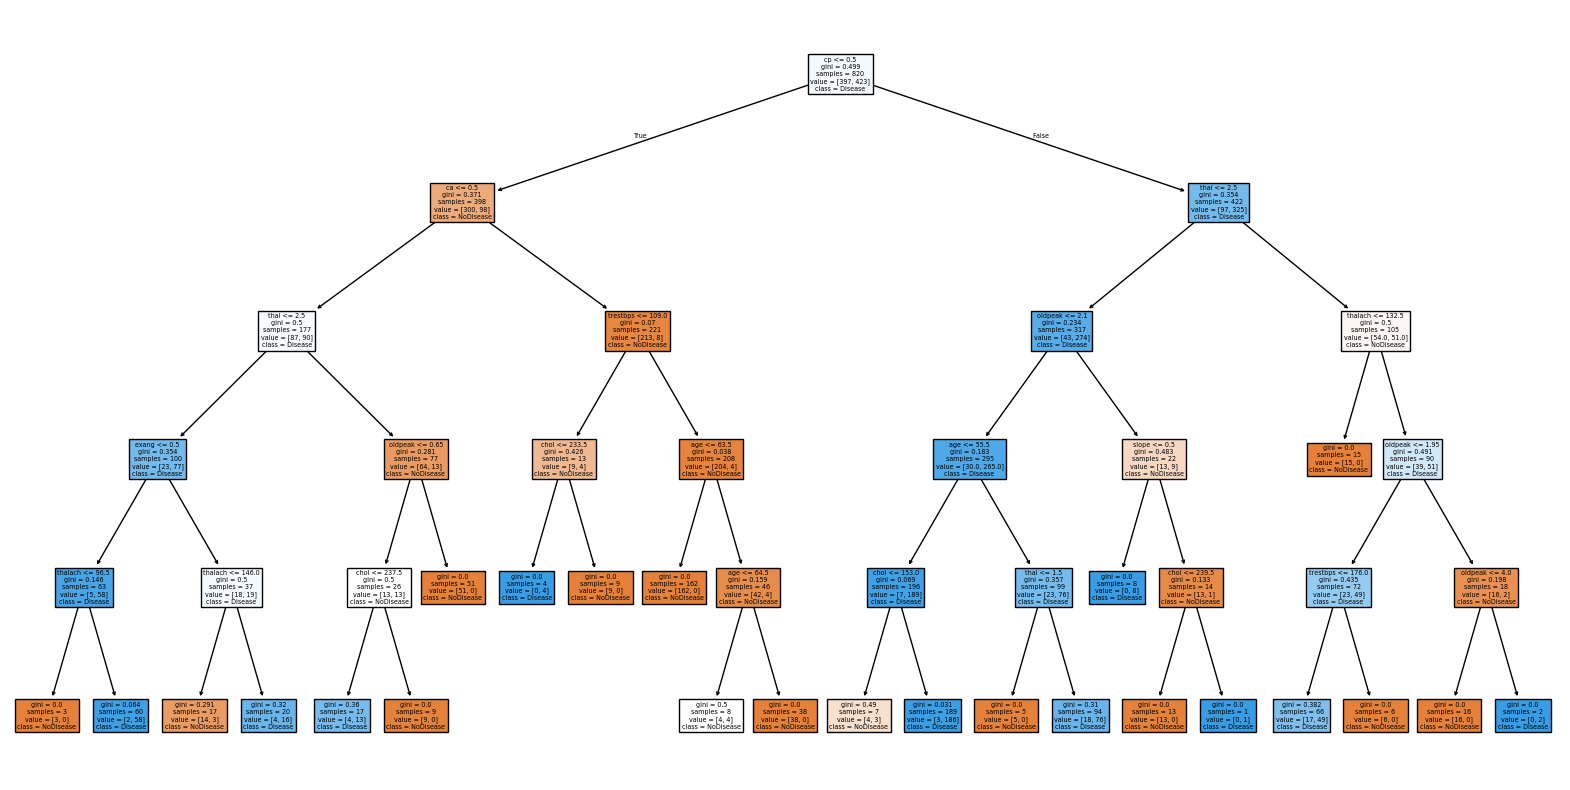

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

best_model = DecisionTreeClassifier(max_depth=5,random_state=42)
best_model.fit(X_train,y_train)

plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["NoDisease","Disease"],
    filled=True
)

plt.show()

## Gini vs Entropy

In [16]:
gini_model = DecisionTreeClassifier(criterion='gini',random_state=42)
entropy_model = DecisionTreeClassifier(criterion='entropy',random_state=42)

gini_model.fit(X_train,y_train)
entropy_model.fit(X_train,y_train)

from sklearn.metrics import accuracy_score

gini_acc = accuracy_score(y_test,gini_model.predict(X_test))
entropy_acc = accuracy_score(y_test,entropy_model.predict(X_test))

print("Gini Accuracy:",gini_acc)
print("Entropy Accuracy:",entropy_acc)

Gini Accuracy: 0.9853658536585366
Entropy Accuracy: 0.9853658536585366


## min_samples_leaf Experiment

In [19]:
leaf_model = DecisionTreeClassifier(min_samples_leaf=5,random_state=42)
leaf_model.fit(X_train,y_train)
leaf_pred = leaf_model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,leaf_pred))

Accuracy: 0.8975609756097561


# Reflection Questions

### 1. Why are Decision Trees suitable for medical datasets?
They produce interpretable decision rules useful for clinical decision making.

### 2. What makes Decision Trees easy to interpret?
Each path from root to leaf represents a clear rule.

### 3. Why are Decision Trees commonly used in ensemble methods?
Many algorithms such as Random Forest combine multiple trees to improve prediction performance.


# Final Conclusion

Decision Trees are effective and interpretable models for classification tasks. By adjusting parameters such as **max_depth** and **min_samples_leaf**, we can control model complexity and reduce overfitting. Experiments with Gini and Entropy showed similar performance on the heart disease dataset, demonstrating the robustness of decision tree classifiers for medical prediction tasks.
